## Fund Analysis Tools

### Setting Up the Environment

In [1]:
import pandas as pd
import plotly.graph_objects as go
from src.fofproject.fund import Fund, input_monthly_returns, subset_of_funds
from src.fofproject.plot import plot_cumulative_returns, plot_fund_correlation_heatmap
from src.fofproject.mvo import minimum_variance_analysis

# Initialize and load data
funds = input_monthly_returns(r"RETURN DATA.csv", performance_fee=0.2, management_fee=0.01)
# funds_to_be_plot = subset_of_funds(funds, ['RDGFF', 'EUREKAHEDGE','MSCI CHINA'])

In [24]:

funds_to_be_plot = subset_of_funds(funds, ['RDGFF', 'EUREKAHEDGE','MSCI CHINA', 'HAO','TAIREN', 'LEXINGTON', 'LIM','FOREST'])
start_month = "2019-12"
end_month = "2020-7"


### Export Monthly Table

In [6]:
# Inception column will add a new column for since inception return
funds['HAO'].export_monthly_table(
    benchmark = funds['MSCI WORLD'],
    inception_column = False,
    )


### Plot Cumulative Retrun Graphs

In [14]:

funds_to_be_plot = subset_of_funds(funds, ['RDGFF', 'EUREKAHEDGE','MSCI CHINA'])
start_month = "2019-12"
end_month = "2020-7"

plot = plot_cumulative_returns(
    funds=funds_to_be_plot,
    title="",
    start_month=start_month,
    end_month=end_month,
    style="pptx",
    language="en",
    blur=True,
    aspect_lock=True,
    custom_ticks=False
    )


### Correlation Heat Map

In [15]:
# Correlation heatmap

funds_to_be_plot = funds
start_month = "2019-12"
end_month = "2020-7"

fig, corr_df, overlap_df = plot_fund_correlation_heatmap(funds_to_be_plot, method="pearson", min_overlap=12)

### Summary of a Fund

(None,
 None,
 Figure({
     'data': [{'histnorm': 'percent',
               'hovertemplate': '<b>%{x.start:.2%} – %{x.end:.2%}</b><br>%{y:.1f}% of months<extra></extra>',
               'marker': {'color': 'rgba(193,174,148,0.55)', 'line': {'color': 'rgba(193,174,148,0.85)', 'width': 0.8}},
               'name': 'HAO',
               'nbinsx': 24,
               'opacity': 0.95,
               'showlegend': False,
               'type': 'histogram',
               'x': {'bdata': ('bHh6pSxDrL+z6nO1Ffu7P9BE2PD0Sq' ... 'm0yHa+n79seHqlLEOMPyV1ApoIG54/'),
                     'dtype': 'f8'}},
              {'hovertemplate': '<b>%{x:.2%}</b><br>%{y:.2f}% (smooth)<extra></extra>',
               'line': {'color': '#C1AE94', 'width': 3},
               'mode': 'lines',
               'name': 'KDE',
               'showlegend': False,
               'type': 'scatter',
               'x': {'bdata': ('w/UoXI/Cxb9lwvJdHZ/FvwePvF+re8' ... 'Lum5rQPzZzDe5UrNA/54wo7Q2+0D8='),
                     'd

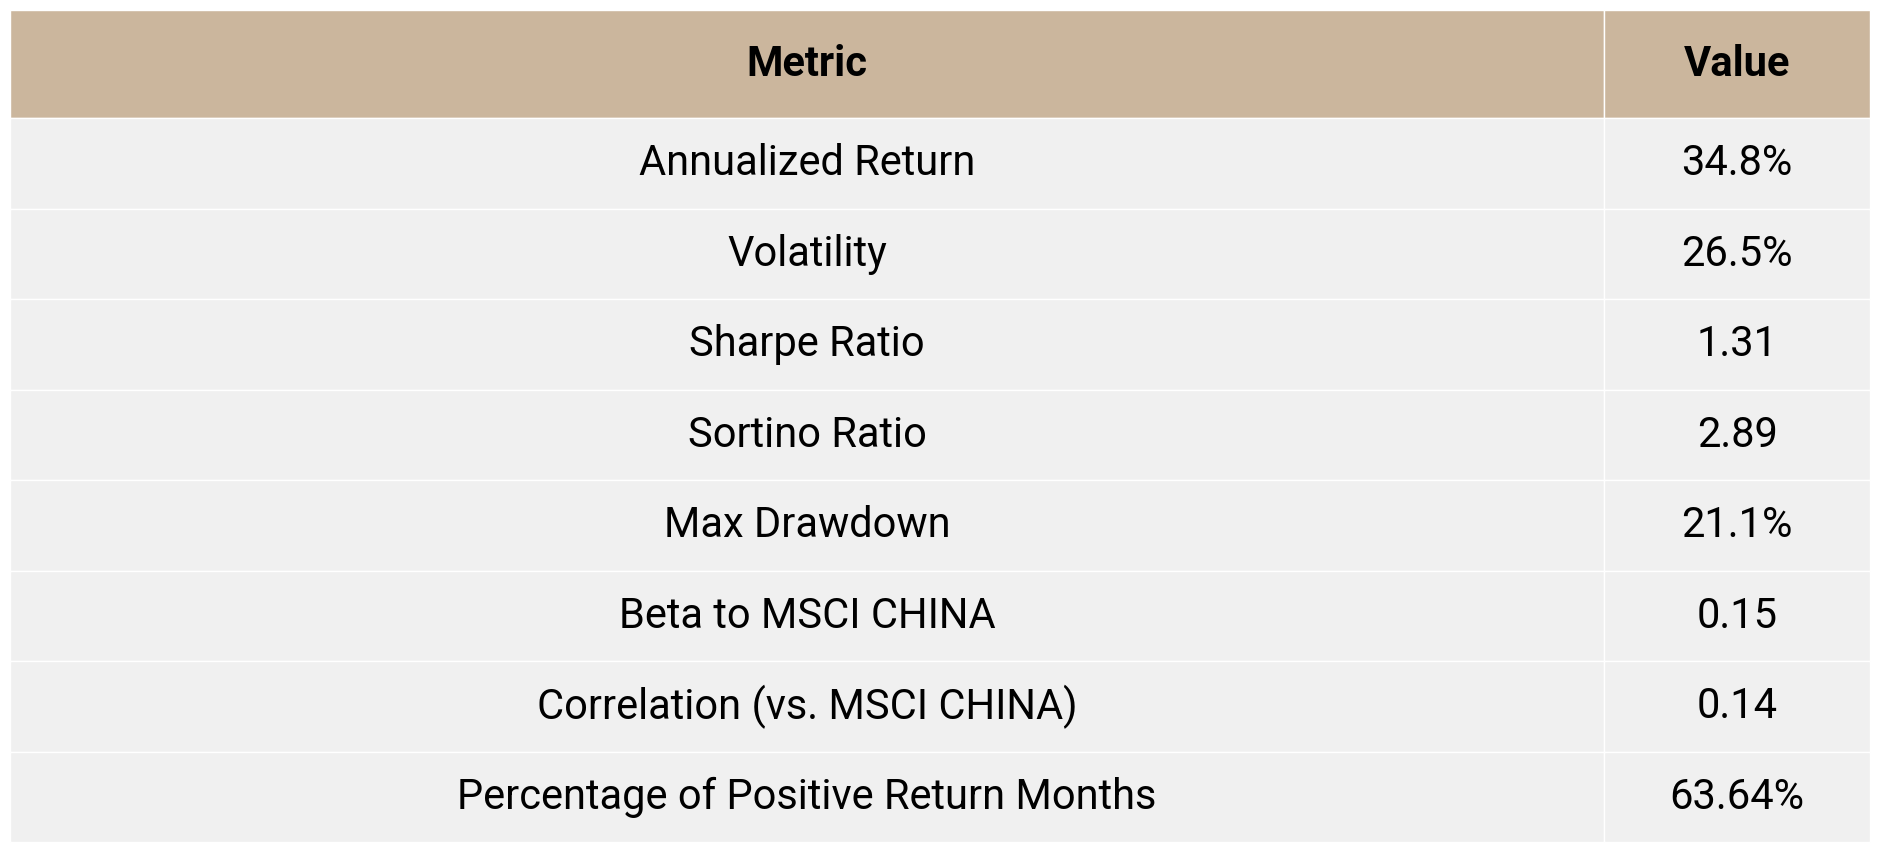

In [16]:
funds['HAO'].summary_of_a_fund(funds['MSCI CHINA'],language="en")

In [ ]:
fig = funds['RDGFF'].plot_rolling_vol_vs_benchmark(benchmark=funds['MSCI WORLD'], window=12)
fig.show()